<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/HF_vs_NF_GE_plot_ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Installing Arial Font for Matplotlib

If you're seeing warnings like `findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial`, it means Matplotlib couldn't locate 'Arial' on your system. Colab environments often don't have all fonts pre-installed.

Here's how you can install it and make it available to Matplotlib:

In [18]:
# 1. Download Arial font files (example: from Google Fonts if available, or upload your own .ttf files)
# As Arial is a proprietary font, direct download links from public repositories can be tricky.
# The most reliable way is to upload your own 'Arial.ttf' file directly to your Colab session (e.g., in the 'files' tab).

# This command installs some common fonts, but NOT Arial. If you need Arial, you MUST upload Arial.ttf.
# !apt-get install -y fonts-crosextra-carlito fonts-crosextra-caladea fonts-noto-color-emoji

# --- IMPORTANT: Upload your Arial.ttf file to /content/ first. ---
# Then, uncomment and run the following line to move it to the system font directory:
# !cp /content/Arial.ttf /usr/local/share/fonts/

print("Please upload your 'Arial.ttf' file to '/content/' and then run the command to copy it to the system fonts.")

Please upload your 'Arial.ttf' file to '/content/' and then run the command to copy it to the system fonts.


In [22]:
# 2. Clear Matplotlib's font cache by deleting the cache file
import matplotlib as mpl
import os

cache_dir = mpl.get_cachedir()
font_cache_file = os.path.join(cache_dir, 'fontlist-v330.json') # Matplotlib versions might change this name

if os.path.exists(font_cache_file):
    os.remove(font_cache_file)
    print(f'✅ Matplotlib font cache file deleted: {font_cache_file}')
else:
    print(f'☑️ Matplotlib font cache file not found at {font_cache_file}. This might be a different version or already cleared.')

# Note: After deleting the cache, you MUST restart the Colab runtime for changes to take effect.

☑️ Matplotlib font cache file not found at /root/.cache/matplotlib/fontlist-v330.json. This might be a different version or already cleared.


After running the above cell, you should restart the runtime (Runtime > Restart runtime) to ensure Matplotlib reloads its font manager correctly with the new fonts.

Then, in the initial setup cell (`6iZsQG0ui2UL`), you can modify `plt.rcParams['font.sans-serif'] = 'Arial'` to include a fallback or ensure 'Arial' is at the beginning of the list if you have uploaded it.

In [23]:
# 3. Verify if Arial is available (optional)
# This cell will list fonts that match 'Arial' after the cache has been rebuilt and runtime restarted.

import matplotlib.font_manager as fm

# Get all font properties. This is more robust than listing raw files.
font_entries = fm.fontManager.ttflist

found_arial = False
for font in font_entries:
    if 'arial' in font.name.lower():
        print(f"Found font: {font.name} at {font.fname}")
        found_arial = True

if not found_arial:
    print("Arial font not explicitly found after cache update. Please ensure 'Arial.ttf' was uploaded and copied correctly, and restart the runtime.")
else:
    print("✅ Arial font should now be available.")


Arial font not explicitly found after cache update. Please ensure 'Arial.ttf' was uploaded and copied correctly, and restart the runtime.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set scientific publication styling
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.0

# Define morph palette
MORPH_COLORS = {
    'Fluorescent': '#2ca02c',       # HF - Green
    'HF': '#2ca02c',
    'Non-fluorescent': '#d62728',   # NF - Red
    'NF': '#d62728'
}

print("✅ Block 1: Environment configured successfully (Font set to Arial/Sans-serif).")

✅ Block 1: Environment configured successfully (Font set to Arial/Sans-serif).


In [57]:
# 1. Load CSV dataset
file_path = 'HF_NF_57_each_plot_ready.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Successfully loaded {file_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find {file_path}. Please upload it to your Colab session.")
    raise

# 2. Clean column headers and text fields
df.columns = df.columns.str.strip()
df['Condition'] = df['Condition'].str.strip()
df['Primary_category'] = df['Primary_category'].str.strip()
df['Description'] = df['Description'].str.strip()

# 3. Standardize log2FoldChange direction (HF positive -> right, NF negative -> left)
# If NF values are positive in raw CSV, negate them for the diverging plot
df['plot_lfc'] = df.apply(
    lambda row: -abs(row['log2FoldChange']) if 'Non' in row['Condition'] or 'NF' in row['Condition']
    else abs(row['log2FoldChange']),
    axis=1
)

# 4. Clean description text for plot labels (strip redundant 'like' or 'LOC' prefixes)
df['Clean_Label'] = df['Description'].str.replace('-like', '', case=False)
df['Clean_Label'] = df['Clean_Label'].str.replace('uncharacterized ', '', case=False)

# 5. Define preferred order for Biological Categories
category_order = [
    'ECM/adhesion',
    'Biomineralization',
    'Cytoskeleton',
    'Metabolism',
    'Morphogenesis',
    'Redox regulation',
    'Immunity',
    'Nuclear/cell cycle',
    'GFP',
    'Neuro-sensing',
    'Other'
]

# Keep categories present in data while preserving order
present_categories = [cat for cat in category_order if cat in df['Primary_category'].unique()]
remaining = [cat for cat in df['Primary_category'].unique() if cat not in present_categories]
final_category_order = present_categories + remaining

print(f"✅ Preprocessed {len(df)} DEGs across {len(final_category_order)} biological categories.")

✅ Successfully loaded HF_NF_57_each_plot_ready.csv
✅ Preprocessed 114 DEGs across 11 biological categories.


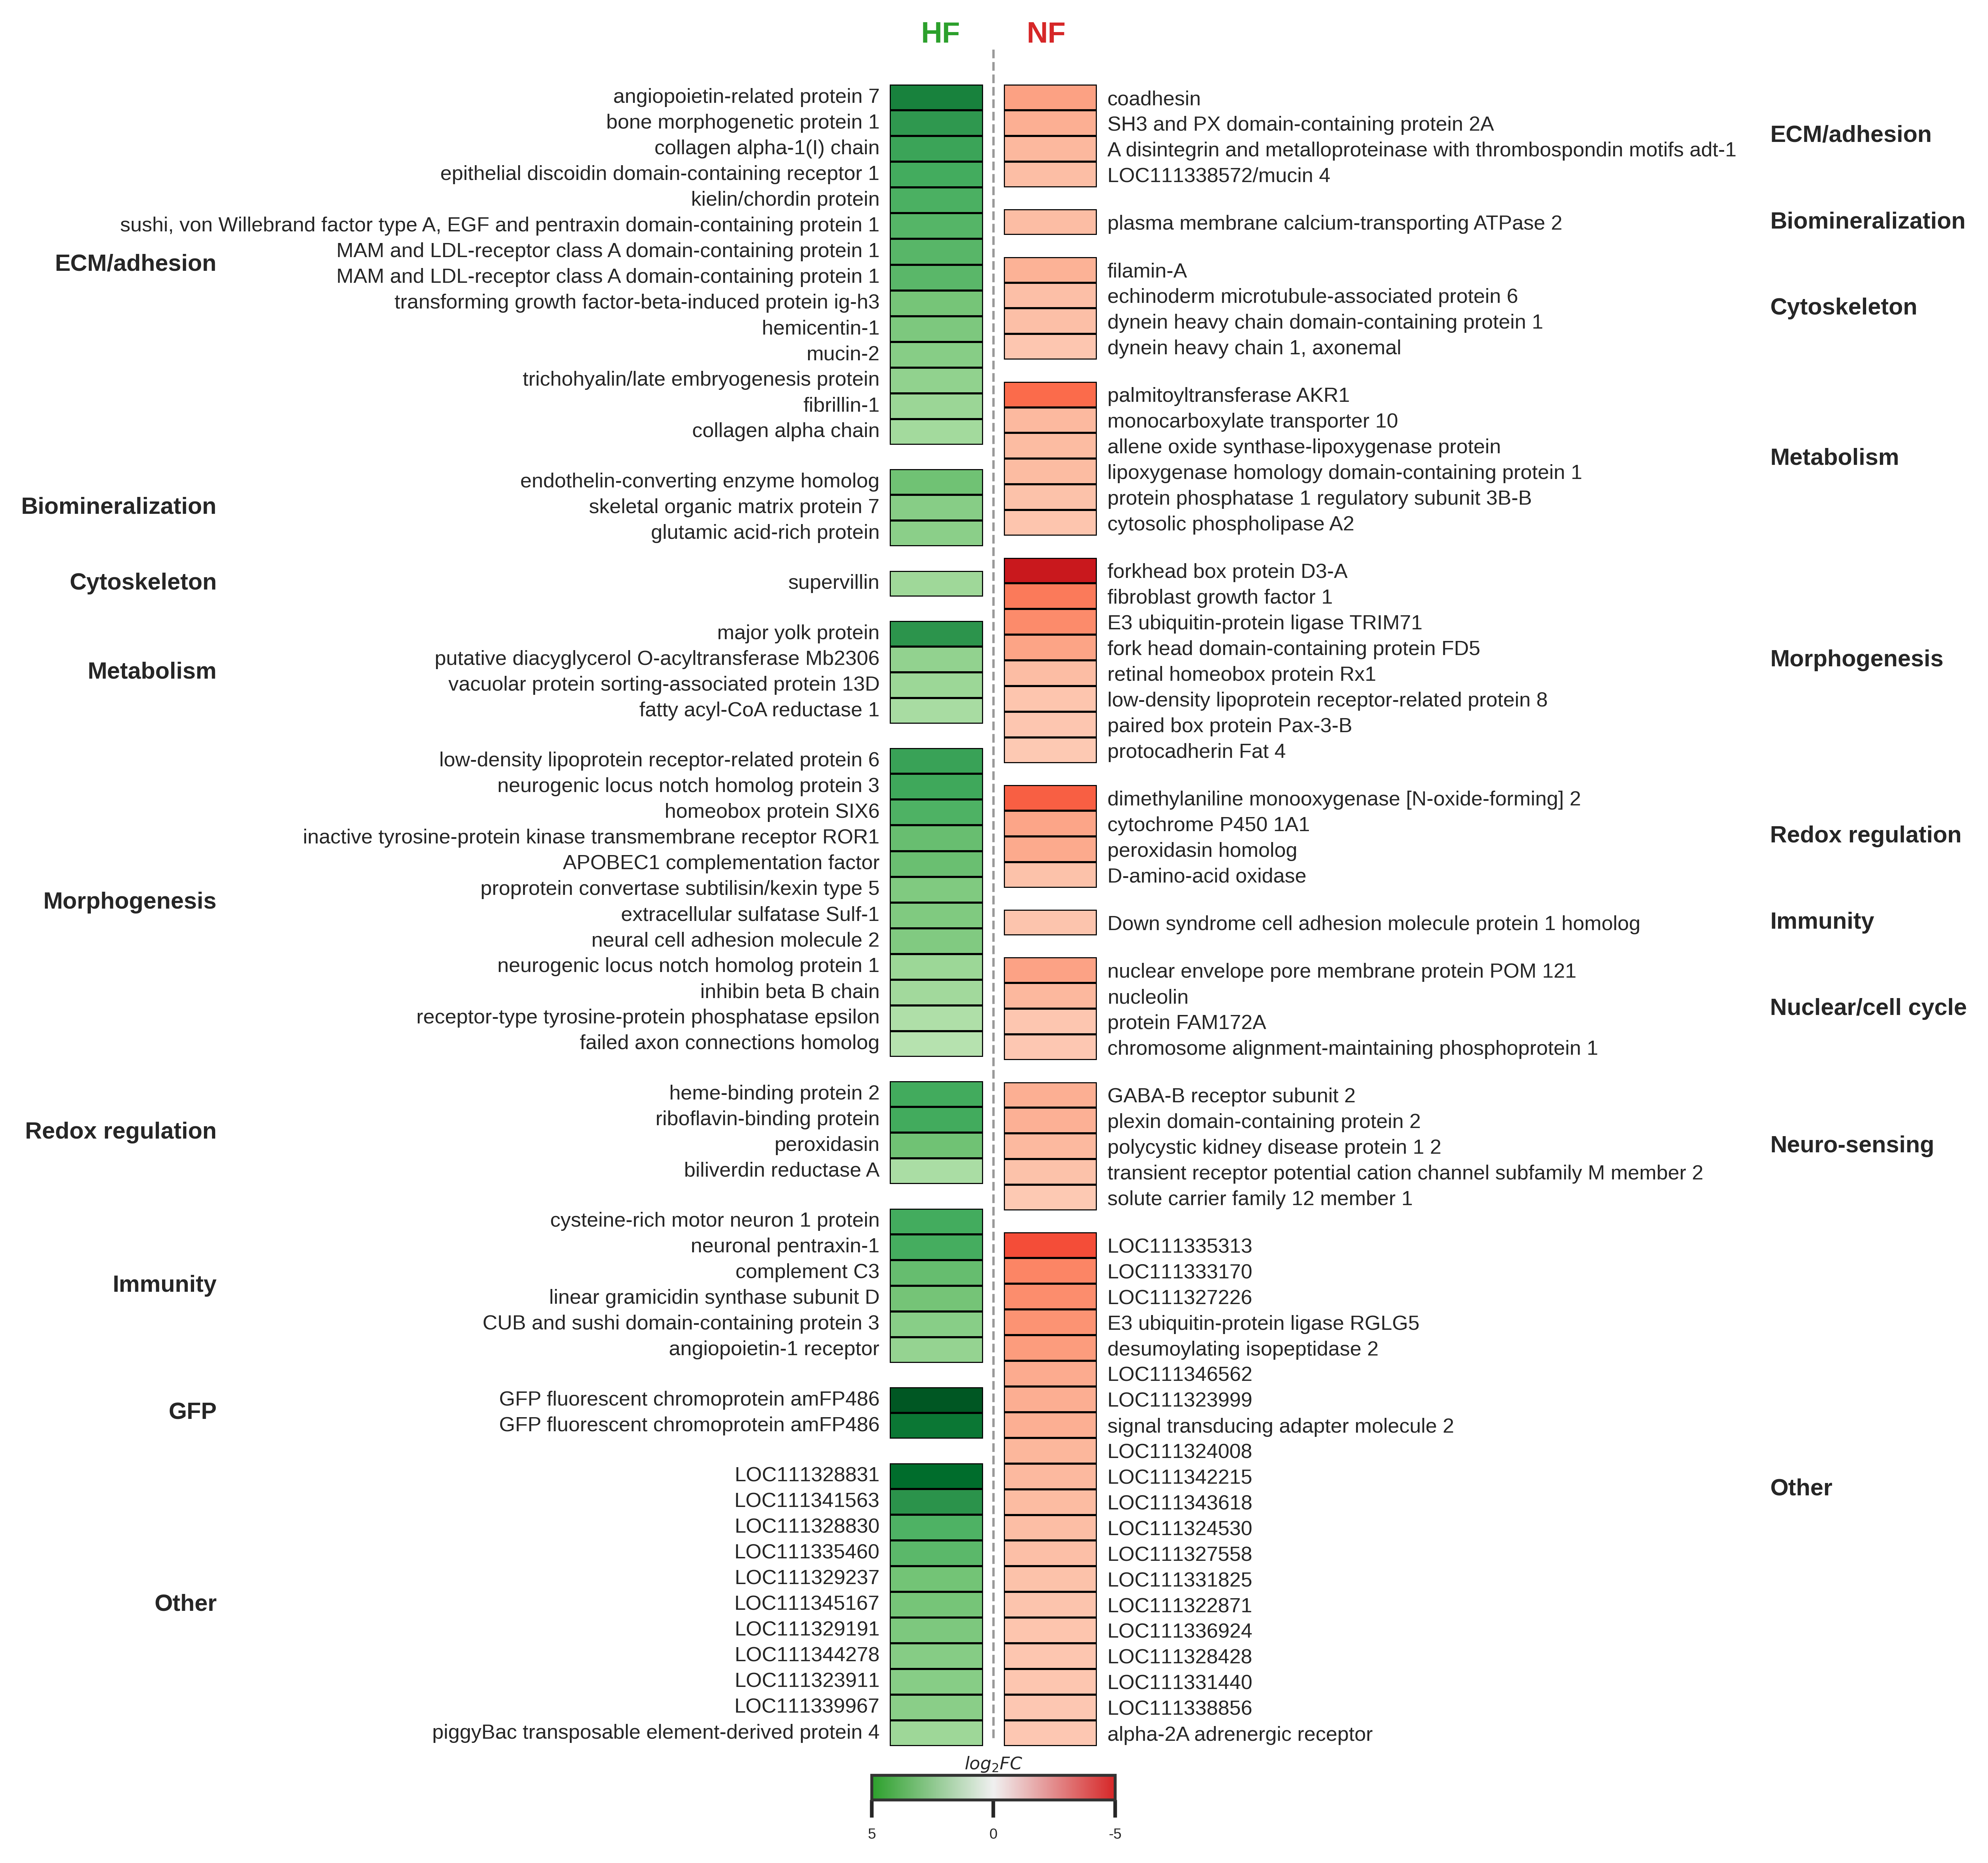

In [231]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- MANUAL ADJUSTMENTS ---
cat_label_offset_hf = 1.3
cat_label_offset_nf = 1.3
center_gap_inch = 0.1      # Horizontal distance between HF/NF heatmap columns and the dashed line
title_y_offset = 0.0001    # Vertical adjustment for HF/NF titles (increase to move up)
title_x_offset = 0.25      # Horizontal distance of titles from center (increase to move to edges)
colorbar_y_offset = 0.1    # Vertical position of colorbar (default 0.04; decrease to move down, increase to move up)
# --------------------------

# 1. Filter genes: HF positive, NF negative
df_hf = df[df['plot_lfc'] > 0].copy()
df_nf = df[df['plot_lfc'] < 0].copy()

# 2. Gene lists per category
hf_plot_cats = [(cat, len(df_hf[df_hf['Primary_category'] == cat])) for cat in final_category_order if len(df_hf[df_hf['Primary_category'] == cat]) > 0]
nf_plot_cats = [(cat, len(df_nf[df_nf['Primary_category'] == cat])) for cat in final_category_order if len(df_nf[df_nf['Primary_category'] == cat]) > 0]

# 3. Geometry
gene_height_inch = 0.15
hm_col_width_inch = gene_height_inch * 3.0
max_total_genes = max(sum(c[1] for c in hf_plot_cats), sum(c[1] for c in nf_plot_cats))

# Height allocations
header_section_height = 0.2
footer_section_height = 0.3
fig_height = (max_total_genes * gene_height_inch) + 1.2

label_width = 2.5
total_fig_width = (label_width * 2) + (hm_col_width_inch * 2) + center_gap_inch

fig = plt.figure(figsize=(total_fig_width, fig_height))

# Main layout grid
main_gs = gridspec.GridSpec(3, 5, figure=fig,
                           height_ratios=[header_section_height, fig_height - header_section_height - footer_section_height, footer_section_height],
                           width_ratios=[label_width, hm_col_width_inch, center_gap_inch, hm_col_width_inch, label_width],
                           wspace=0.0, hspace=0.0)

category_hspace = 0.15

# Subgrids
gs_cat_l = gridspec.GridSpecFromSubplotSpec(len(hf_plot_cats), 1, subplot_spec=main_gs[1, 0], height_ratios=[c[1] for c in hf_plot_cats], hspace=category_hspace)
gs_hf = gridspec.GridSpecFromSubplotSpec(len(hf_plot_cats), 1, subplot_spec=main_gs[1, 1], height_ratios=[c[1] for c in hf_plot_cats], hspace=category_hspace)
gs_nf = gridspec.GridSpecFromSubplotSpec(len(nf_plot_cats), 1, subplot_spec=main_gs[1, 3], height_ratios=[c[1] for c in nf_plot_cats], hspace=category_hspace)
gs_cat_r = gridspec.GridSpecFromSubplotSpec(len(nf_plot_cats), 1, subplot_spec=main_gs[1, 4], height_ratios=[c[1] for c in nf_plot_cats], hspace=category_hspace)

cbar_min, cbar_max = -5, 5
cmap_div_rev = LinearSegmentedColormap.from_list('rev_green_red', ['#2ca02c', '#f0f0f0', '#d62728'])

# --- HF/NF Titles (TOP) ---
mid_x_fig = (label_width + hm_col_width_inch + (center_gap_inch / 2)) / total_fig_width
title_x_hf = mid_x_fig - (title_x_offset / total_fig_width)
title_x_nf = mid_x_fig + (title_x_offset / total_fig_width)
title_y_base = 0.95 + title_y_offset

fig.text(title_x_hf, title_y_base, 'HF', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2ca02c')
fig.text(title_x_nf, title_y_base, 'NF', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d62728')

# --- Colorbar (BOTTOM) ---
cbar_ax = fig.add_axes([0.404, colorbar_y_offset, 0.192, 0.012])
smb = plt.cm.ScalarMappable(cmap=cmap_div_rev, norm=plt.Normalize(vmin=cbar_min, vmax=cbar_max))
cbar = fig.colorbar(smb, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([cbar_min, 0, cbar_max])
cbar.set_ticklabels([5, 0, -5])
cbar_ax.set_title('$log_2{FC}$', fontsize=6, pad=2)
cbar.ax.tick_params(labelsize=5)

# --- Central Divider ---
mid_x = (label_width + hm_col_width_inch + (center_gap_inch / 2)) / total_fig_width
# Further adjusted ymin from 0.15 to 0.2 to ensure no overlap with color bar area
fig.add_artist(plt.Line2D((mid_x, mid_x), (0.13, 0.95), color='black', alpha=0.4, lw=0.8, linestyle='--', transform=fig.transFigure, zorder=0))

# --- Plots ---
for i, (cat, count) in enumerate(hf_plot_cats):
    ax_cat = fig.add_subplot(gs_cat_l[i])
    ax_cat.axis('off')
    ax_cat.text(1.0 - cat_label_offset_hf, 0.5, cat, transform=ax_cat.transAxes, fontsize=8, fontweight='bold', ha='right', va='center')
    cat_data = df_hf[df_hf['Primary_category'] == cat].sort_values(by='plot_lfc', ascending=False)
    ax_hm = fig.add_subplot(gs_hf[i])
    sns.heatmap(cat_data['plot_lfc'].values.reshape(-1, 1), cmap='Greens', vmin=0, vmax=cbar_max, cbar=False, ax=ax_hm, xticklabels=False, yticklabels=cat_data['Clean_Label'].values, linewidths=0.5, linecolor='black')
    ax_hm.tick_params(axis='y', labelsize=7, rotation=0, length=0)

for i, (cat, count) in enumerate(nf_plot_cats):
    cat_data = df_nf[df_nf['Primary_category'] == cat].sort_values(by='plot_lfc', ascending=True)
    ax_hm = fig.add_subplot(gs_nf[i])
    sns.heatmap(cat_data['plot_lfc'].abs().values.reshape(-1, 1), cmap='Reds', vmin=0, vmax=cbar_max, cbar=False, ax=ax_hm, xticklabels=False, yticklabels=cat_data['Clean_Label'].values, linewidths=0.5, linecolor='black')
    ax_hm.yaxis.tick_right()
    ax_hm.tick_params(axis='y', labelsize=7, rotation=0, length=0)
    ax_cat = fig.add_subplot(gs_cat_r[i])
    ax_cat.axis('off')
    ax_cat.text(cat_label_offset_nf, 0.5, cat, transform=ax_cat.transAxes, fontsize=8, fontweight='bold', ha='left', va='center')

plt.subplots_adjust(top=0.95, bottom=0.1, left=0.01, right=0.99)
plt.show()

### Exporting Final Visualization
Saving the figure in high-resolution (600 DPI) for publication.

In [232]:
# Define filename base
output_filename = 'Gene_Expression_Split_Heatmap'

# Save in multiple formats at 600 DPI
fig.savefig(f'{output_filename}.png', dpi=600, bbox_inches='tight', format='png')
fig.savefig(f'{output_filename}.svg', dpi=600, bbox_inches='tight', format='svg')
fig.savefig(f'{output_filename}.tiff', dpi=600, bbox_inches='tight', format='tiff')

print(f"✅ Successfully saved plot as:")
print(f" - {output_filename}.png")
print(f" - {output_filename}.svg")
print(f" - {output_filename}.tiff")

✅ Successfully saved plot as:
 - Gene_Expression_Split_Heatmap.png
 - Gene_Expression_Split_Heatmap.svg
 - Gene_Expression_Split_Heatmap.tiff
